In [1]:
import kagglehub
path = kagglehub.dataset_download("jangedoo/utkface-new")

In [2]:
# ===================== PART 1: SETUP (Colab GPU) =====================
!pip install -q albumentations tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import pandas as pd
import numpy as np
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import os
import zipfile
from pathlib import Path

# Use GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using: {device}")
if device.type == 'cuda':
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ No GPU detected. Please go to Runtime -> Change runtime type and select 'GPU' for hardware accelerator.")

✅ Using: cuda
GPU Name: Tesla T4


## Dataset Extraction and Loading (UTKFace Only)

First, we need to extract the UTKFace dataset from the provided zip file (`/content/archive (7).zip`) and then load its metadata into a pandas DataFrame. We'll then split this data into training, validation, and test sets. We're focusing solely on UTKFace as per your request.

In [2]:
# ===================== PART 2: LOAD UTKFACE =====================

# The UTKFace dataset is downloaded via kagglehub and its content is typically
# found under the 'UTKFace' subdirectory within the downloaded path.
utk_folder = os.path.join(path, "UTKFace")

data = []

print("Loading UTKFace images...")
for filename in tqdm(os.listdir(utk_folder)):
    if filename.endswith('.jpg'):
        try:
            parts = filename.split('_')
            age = int(parts[0])
            gender = int(parts[1])  # 0=Male, 1=Female

            data.append({
                'image_path': os.path.join(utk_folder, filename),
                'age': age,
                'gender': gender
            })
        except:
            continue

df = pd.DataFrame(data)
print(f"\nTotal Images: {len(df)}")

# Split
train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42, stratify=df['gender'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['gender'])

print(f"Train: {len(train_df)} | Validation: {len(val_df)} | Test: {len(test_df)}")

NameError: name 'os' is not defined

In [4]:
# ===================== PART 3: MODEL + DATASET (Fixed) =====================

# ------------------- Dataset Class -------------------
class AgeGenderDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        img = np.array(img)

        if self.transform:
            augmented = self.transform(image=img)
            img = augmented['image']

        age = torch.tensor(float(row['age']), dtype=torch.float32)
        gender = torch.tensor(row['gender'], dtype=torch.long)

        return img, age, gender

# ------------------- Augmentations (Fixed) -------------------
train_transform = A.Compose([
    A.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0)),   # Fixed version: uses 'size' parameter
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.4),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(height=256, width=256),
    A.CenterCrop(height=224, width=224),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# ------------------- Multi-Task Model -------------------
class AgeGenderModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.efficientnet_b3(weights='IMAGENET1K_V1')
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()

        self.dropout = nn.Dropout(0.5)

        self.gender_head = nn.Linear(in_features, 2)
        self.age_head = nn.Linear(in_features, 1)   # Regression

    def forward(self, x):
        x = self.backbone(x)
        x = self.dropout(x)
        gender_out = self.gender_head(x)
        age_out = self.age_head(x)
        return gender_out, age_out

model = AgeGenderModel().to(device)
print("✅ Model (EfficientNet-B3) Created Successfully!")
print("Total Parameters:", sum(p.numel() for p in model.parameters()))

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 177MB/s]


✅ Model (EfficientNet-B3) Created Successfully!
Total Parameters: 10700843


In [6]:
import os
import pandas as pd
from tqdm import tqdm

# Correct Path
utk_folder = "/kaggle/input/datasets/jangedoo/utkface-new/UTKFace"

data = []

print("Scanning UTKFace folder...")

for filename in tqdm(os.listdir(utk_folder)):
    if filename.endswith('.jpg'):
        try:
            parts = filename.split('_')
            age = int(parts[0])
            gender = int(parts[1])   # 0 = Male, 1 = Female
            
            data.append({
                'image_path': os.path.join(utk_folder, filename),
                'age': age,
                'gender': gender
            })
        except:
            continue

df = pd.DataFrame(data)
print(f"\nTotal images processed: {len(df)}")

# Gender Distribution
print("\n=== GENDER DISTRIBUTION ===")
print(df['gender'].value_counts())
print("0 = Male | 1 = Female")
print(f"Male Percentage:   {(df['gender'] == 0).sum()/len(df)*100 :.2f}%")
print(f"Female Percentage: {(df['gender'] == 1).sum()/len(df)*100 :.2f}%")

# Save CSV
df.to_csv('/kaggle/working/utk_labels.csv', index=False)
print("\n✅ CSV file saved successfully at: /kaggle/working/utk_labels.csv")

Scanning UTKFace folder...


100%|██████████| 23708/23708 [00:00<00:00, 224571.72it/s]



Total images processed: 23708

=== GENDER DISTRIBUTION ===
gender
0    12391
1    11317
Name: count, dtype: int64
0 = Male | 1 = Female
Male Percentage:   52.27%
Female Percentage: 47.73%

✅ CSV file saved successfully at: /kaggle/working/utk_labels.csv


In [8]:
# ===================== PART 4: TRAINING WITH EARLY STOPPING =====================

train_dataset = AgeGenderDataset(train_df, transform=train_transform)
val_dataset = AgeGenderDataset(val_df, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# Loss, Optimizer
criterion_gender = nn.CrossEntropyLoss()
criterion_age = nn.SmoothL1Loss()

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

# ===================== EARLY STOPPING =====================
patience = 6
best_val_mae = float('inf')
epochs_no_improve = 0
early_stop = False

num_epochs = 25

for epoch in range(num_epochs):
    if early_stop:
        break
        
    model.train()
    train_loss = 0.0
    correct_gender = 0
    total_gender = 0
    age_mae_sum = 0.0
    
    for images, ages, genders in tqdm(train_loader):
        images = images.to(device)
        ages = ages.to(device).unsqueeze(1)
        genders = genders.to(device)
        
        optimizer.zero_grad()
        
        gender_pred, age_pred = model(images)
        
        loss_gender = criterion_gender(gender_pred, genders)
        loss_age = criterion_age(age_pred, ages)
        total_loss = loss_gender + 0.8 * loss_age
        
        total_loss.backward()
        optimizer.step()
        
        train_loss += total_loss.item()
        _, predicted_gender = torch.max(gender_pred, 1)
        correct_gender += (predicted_gender == genders).sum().item()
        total_gender += genders.size(0)
        age_mae_sum += torch.mean(torch.abs(age_pred - ages)).item()
    
    # Validation Phase
    model.eval()
    val_gender_correct = 0
    val_total = 0
    val_age_mae = 0.0
    
    with torch.no_grad():
        for images, ages, genders in val_loader:
            images = images.to(device)
            ages = ages.to(device).unsqueeze(1)
            genders = genders.to(device)
            
            gender_pred, age_pred = model(images)
            
            _, predicted = torch.max(gender_pred, 1)
            val_gender_correct += (predicted == genders).sum().item()
            val_total += genders.size(0)
            val_age_mae += torch.mean(torch.abs(age_pred - ages)).item()
    
    avg_val_mae = val_age_mae / len(val_loader)
    
    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss/len(train_loader):.4f} | Gender Acc: {100*correct_gender/total_gender:.2f}%")
    print(f"Val Gender Acc: {100*val_gender_correct/val_total:.2f}% | Val Age MAE: {avg_val_mae:.4f}")
    
    # Early Stopping Check
    if avg_val_mae < best_val_mae:
        best_val_mae = avg_val_mae
        epochs_no_improve = 0
        torch.save(model.state_dict(), '/content/best_age_gender_model.pth')
        print(f"✅ Best model saved! (Val MAE: {best_val_mae:.4f})")
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epoch(s)")
        
        if epochs_no_improve >= patience:
            print(f"\n🛑 Early Stopping triggered! No improvement for {patience} epochs.")
            early_stop = True

print("\n🎉 Training Completed!")
print(f"Best Validation Age MAE: {best_val_mae:.4f}")

100%|██████████| 593/593 [03:29<00:00,  2.84it/s]



Epoch [1/25]
Train Loss: 4.2371 | Gender Acc: 89.71%
Val Gender Acc: 90.51% | Val Age MAE: 5.6360
✅ Best model saved! (Val MAE: 5.6360)


100%|██████████| 593/593 [03:27<00:00,  2.86it/s]



Epoch [2/25]
Train Loss: 3.9539 | Gender Acc: 90.42%
Val Gender Acc: 91.69% | Val Age MAE: 4.9466
✅ Best model saved! (Val MAE: 4.9466)


100%|██████████| 593/593 [03:28<00:00,  2.85it/s]


...


Epoch [23/25]
Train Loss: 1.9004 | Gender Acc: 96.07%
Val Gender Acc: 92.45% | Val Age MAE: 4.6981
No improvement for 1 epoch(s)


100%|██████████| 593/593 [03:27<00:00,  2.85it/s]



Epoch [24/25]
Train Loss: 1.8329 | Gender Acc: 96.34%
Val Gender Acc: 92.79% | Val Age MAE: 4.7875
No improvement for 2 epoch(s)


100%|██████████| 593/593 [03:28<00:00,  2.84it/s]



Epoch [25/25]
Train Loss: 1.7899 | Gender Acc: 96.31%
Val Gender Acc: 93.13% | Val Age MAE: 4.7633
No improvement for 3 epoch(s)

🎉 Training Completed!
Best Validation Age MAE: 4.6831


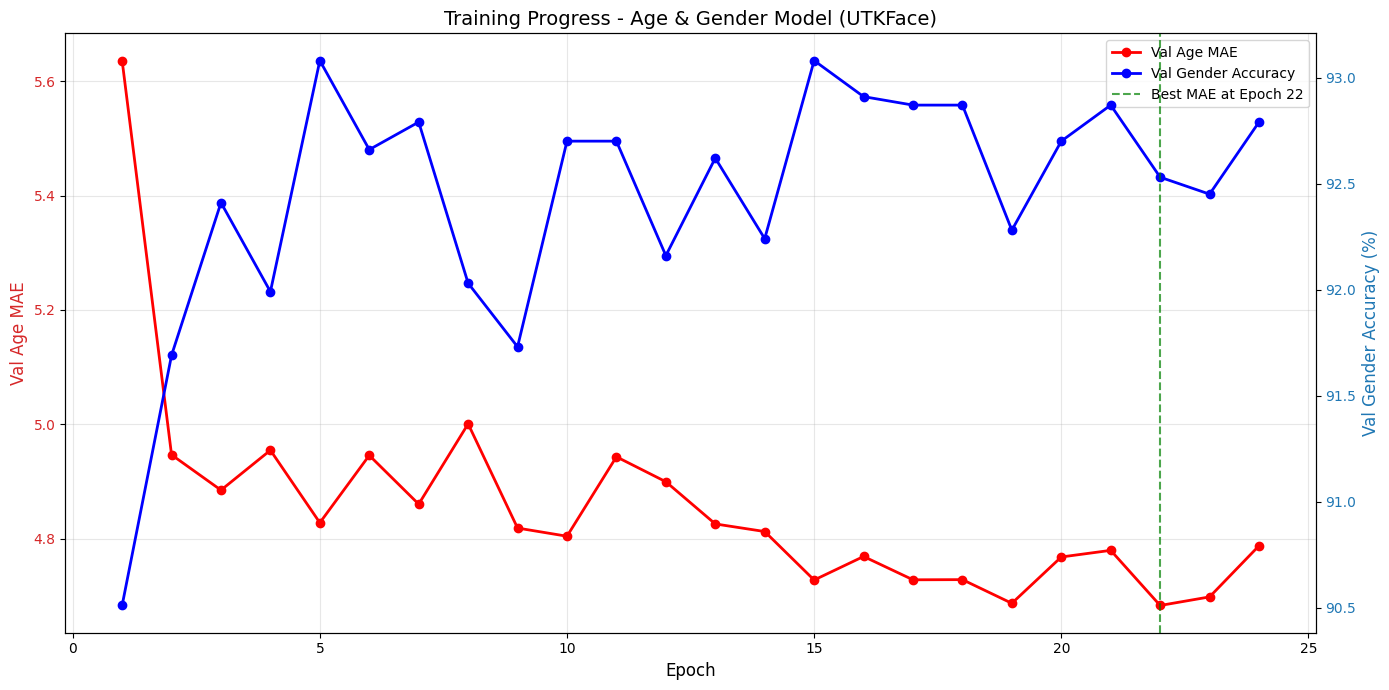

Best Age MAE: 4.6831 at Epoch 22


In [3]:
import matplotlib.pyplot as plt

# ===================== COPY YOUR VALUES HERE =====================
epochs = list(range(1, 25))

val_age_mae = [5.6360, 4.9466, 4.8848, 4.9546, 4.8278, 4.9456, 4.8603, 5.0007, 4.8185, 4.8042,
               4.9431, 4.8995, 4.8257, 4.8124, 4.7276, 4.7688, 4.7280, 4.7283, 4.6869, 4.7679,
               4.7795, 4.6831, 4.6981, 4.7875]

val_gender_acc = [90.51, 91.69, 92.41, 91.99, 93.08, 92.66, 92.79, 92.03, 91.73, 92.70,
                  92.70, 92.16, 92.62, 92.24, 93.08, 92.91, 92.87, 92.87, 92.28, 92.70,
                  92.87, 92.53, 92.45, 92.79]

# ===================== PLOT =====================
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot Age MAE
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Val Age MAE', color='tab:red', fontsize=12)
ax1.plot(epochs, val_age_mae, 'r-o', label='Val Age MAE', linewidth=2)
ax1.tick_params(axis='y', labelcolor='tab:red')

# Second axis for Gender Accuracy
ax2 = ax1.twinx()
ax2.set_ylabel('Val Gender Accuracy (%)', color='tab:blue', fontsize=12)
ax2.plot(epochs, val_gender_acc, 'b-o', label='Val Gender Accuracy', linewidth=2)
ax2.tick_params(axis='y', labelcolor='tab:blue')

# Highlight best MAE
best_mae = min(val_age_mae)
best_epoch = epochs[val_age_mae.index(best_mae)]
plt.axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7, label=f'Best MAE at Epoch {best_epoch}')

plt.title('Training Progress - Age & Gender Model (UTKFace)', fontsize=14)
ax1.grid(True, alpha=0.3)

# Legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

print(f"Best Age MAE: {best_mae:.4f} at Epoch {best_epoch}")

In [5]:
import os

model_path = '/content/best_age_gender_model.pth'

if os.path.exists(model_path):
    print(f"✅ Model found at: {model_path}")
else:
    print(f"❌ Model not found at: {model_path}. It might have been lost due to runtime restart.")

❌ Model not found at: /content/best_age_gender_model.pth. It might have been lost due to runtime restart.


In [11]:
# ===================== REAL-TIME VIDEO INFERENCE =====================
import cv2
import torch
from torchvision import transforms
import numpy as np

# Load best model
model = AgeGenderModel().to(device)
model.load_state_dict(torch.load('/content/best_age_gender_model.pth', map_location=device))
model.eval()

# Preprocessing for inference
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Face Detector (Fast)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

cap = cv2.VideoCapture(0)  # 0 = webcam

print("Press 'q' to quit")

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    
    for (x, y, w, h) in faces:
        face = frame[y:y+h, x:x+w]
        face_rgb = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
        face_pil = Image.fromarray(face_rgb)
        
        input_tensor = inference_transform(face_pil).unsqueeze(0).to(device)
        
        with torch.no_grad():
            gender_pred, age_pred = model(input_tensor)
        
        gender = "Male" if torch.argmax(gender_pred, 1).item() == 0 else "Female"
        age = int(age_pred.item())
        
        # Draw rectangle and text
        color = (0, 255, 0) if gender == "Male" else (255, 0, 255)
        cv2.rectangle(frame, (x, y), (x+w, y+h), color, 2)
        cv2.putText(frame, f"{gender}, {age}y", (x, y-10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
    
    cv2.imshow('Age & Gender Real-Time', frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Press 'q' to quit


[ WARN:0@6960.643] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video0): can't open camera by index
[ WARN:0@6960.720] global cap.cpp:438 open VIDEOIO(FFMPEG): raised OpenCV exception:

OpenCV(4.13.0) /io/opencv/modules/videoio/src/cap_ffmpeg_impl.hpp:1220: error: (-2:Unspecified error) in function 'bool CvCapture_FFMPEG::open(const char*, int, const cv::Ptr<cv::IStreamReader>&, const cv::VideoCaptureParameters&)'
> VIDEOIO/FFMPEG: Camera index out of range (expected: 'index < device_list->nb_devices'), where
>     'index' is 0
> must be less than
>     'device_list->nb_devices' is 0


[ERROR:0@6960.721] global obsensor_uvc_stream_channel.cpp:163 getStreamChannelGroup Camera index out of range


In [6]:
import os

print("Checking possible locations...")

paths_to_check = [
    '/kaggle/working/best_age_gender_model.pth',
    '/content/best_age_gender_model.pth',
    'best_age_gender_model.pth'
]

for p in paths_to_check:
    if os.path.exists(p):
        print(f"✅ Model found at: {p}")
        print(f"Size: {os.path.getsize(p)/ (1024*1024):.2f} MB")
    else:
        print(f"❌ Not found: {p}")

Checking possible locations...
❌ Not found: /kaggle/working/best_age_gender_model.pth
❌ Not found: /content/best_age_gender_model.pth
❌ Not found: best_age_gender_model.pth


In [7]:
import shutil
import os

source = '/content/best_age_gender_model.pth'
destination = '/kaggle/working/best_age_gender_model.pth'

shutil.copy(source, destination)
print("✅ Model copied to Kaggle working directory!")

# Verify
if os.path.exists(destination):
    print(f"✅ Success! File Size: {os.path.getsize(destination)/(1024*1024):.2f} MB")
else:
    print("❌ Copy failed")

FileNotFoundError: [Errno 2] No such file or directory: '/content/best_age_gender_model.pth'

In [1]:
# ===================== TEST ON VIDEO FILE (Kaggle) =====================
import cv2
import torch
from PIL import Image
import torchvision.transforms as transforms
import numpy as np

# Load your best model
model = AgeGenderModel().to(device)
model.load_state_dict(torch.load('/kaggle/working/best_age_gender_model.pth', map_location=device))
model.eval()

# Transform
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# === CHANGE THIS TO YOUR VIDEO PATH ===
video_path = "/kaggle/input/your-video/video.mp4"   # Upload a video first

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Cannot open video")
else:
    print("Video opened successfully")

frame_count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    frame_count += 1
    if frame_count % 3 != 0:   # Process every 3rd frame for speed
        continue
    
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml').detectMultiScale(gray, 1.3, 5)
    
    for (x, y, w, h) in faces:
        face = frame[y:y+h, x:x+w]
        face_rgb = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
        face_pil = Image.fromarray(face_rgb)
        
        input_tensor = inference_transform(face_pil).unsqueeze(0).to(device)
        
        with torch.no_grad():
            gender_pred, age_pred = model(input_tensor)
        
        gender = "Male" if torch.argmax(gender_pred, 1).item() == 0 else "Female"
        age = max(1, int(age_pred.item()))   # avoid negative ages
        
        color = (0, 255, 0) if gender == "Male" else (255, 0, 255)
        cv2.rectangle(frame, (x, y), (x+w, y+h), color, 2)
        cv2.putText(frame, f"{gender}, {age}", (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)
    
    cv2.imshow('Age & Gender Detection', frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
print("Video Processing Finished")

NameError: name 'AgeGenderModel' is not defined